In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [3]:
df=pd.read_csv('/content/drive/MyDrive/StudentPerformanceFactors.csv')

In [4]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Data profiling

In [5]:
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


In [6]:
df.shape

(6607, 20)

In [7]:
df.describe(include='object')

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


In [8]:
cat = df.select_dtypes(include = ['object']).columns
cat.to_list()

['Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Motivation_Level',
 'Internet_Access',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender']

In [9]:
for col in cat:
  print(f'{col}: {df[col].unique()}')

Parental_Involvement: ['Low' 'Medium' 'High']
Access_to_Resources: ['High' 'Medium' 'Low']
Extracurricular_Activities: ['No' 'Yes']
Motivation_Level: ['Low' 'Medium' 'High']
Internet_Access: ['Yes' 'No']
Family_Income: ['Low' 'Medium' 'High']
Teacher_Quality: ['Medium' 'High' 'Low' nan]
School_Type: ['Public' 'Private']
Peer_Influence: ['Positive' 'Negative' 'Neutral']
Learning_Disabilities: ['No' 'Yes']
Parental_Education_Level: ['High School' 'College' 'Postgraduate' nan]
Distance_from_Home: ['Near' 'Moderate' 'Far' nan]
Gender: ['Male' 'Female']


In [10]:
for col in cat:
  print(f'{df[col].value_counts()}')

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64
Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64
School_Type
Public     4598
Private    2009
Name: count, dtype: int64
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64
Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64
Distance_from_Home
Near        3884
Moderate    1998
Far          

In [11]:
num = df.select_dtypes(include = ['int64']).columns
num.to_list()

['Hours_Studied',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity',
 'Exam_Score']

In [12]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [13]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [14]:
df['Family_Income'].value_counts()

,count
Family_Income,
Low,2672
Medium,2666
High,1269


# Data cleansing

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
Q1 = df["Exam_Score"].quantile(0.25)
Q3 = df["Exam_Score"].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [17]:
no_outliers = df[(df["Exam_Score"] >= lower_limit) & (df["Exam_Score"] <= upper_limit)]

In [18]:
df["Exam_Score"] = df["Exam_Score"].clip(lower=lower_limit, upper=upper_limit)

In [19]:
#Teacher_Quality: ['Medium' 'High' 'Low' nan]
df[df['Teacher_Quality'].isnull()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
127,17,97,Medium,Medium,No,8,89,Medium,Yes,1,Low,NaN,Public,Neutral,4,No,High School,Far,Male,69
396,10,80,High,Medium,Yes,6,93,High,Yes,4,Medium,NaN,Public,Negative,3,No,College,Moderate,Female,67
457,14,86,Medium,Low,Yes,8,90,Medium,No,3,Medium,NaN,Public,Negative,3,Yes,Postgraduate,Near,Male,65
570,20,71,High,Medium,No,8,77,Medium,Yes,0,High,NaN,Private,Neutral,4,No,High School,Moderate,Male,66
593,22,82,High,Medium,Yes,7,71,Low,Yes,1,High,NaN,Private,Positive,3,No,High School,Near,Female,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6414,22,63,Low,Low,Yes,7,94,Medium,Yes,0,Medium,NaN,Public,Negative,3,Yes,High School,Far,Male,61
6427,29,75,Low,Medium,Yes,7,96,Low,Yes,2,Low,NaN,Public,Positive,3,No,High School,Moderate,Male,68
6461,12,89,Medium,High,Yes,8,78,Low,Yes,4,Low,NaN,Public,Neutral,5,No,Postgraduate,Near,Female,69
6579,9,84,Medium,Medium,No,6,74,Medium,Yes,5,High,NaN,Public,Neutral,2,No,High School,Near,Male,67


In [20]:
df['Teacher_Quality'].mode()[0]

'Medium'

In [21]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])

In [22]:
df['Parental_Education_Level'].value_counts()

,count
Parental_Education_Level,
High School,3223
College,1989
Postgraduate,1305


In [23]:
df['Parental_Education_Level'].value_counts()

,count
Parental_Education_Level,
High School,3223
College,1989
Postgraduate,1305


In [24]:
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])

In [25]:
df['Distance_from_Home'].value_counts()

,count
Distance_from_Home,
Near,3884
Moderate,1998
Far,658


In [26]:
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

In [27]:
for col in cat:
  print(f'{col}: {df[col].unique()}')

Parental_Involvement: ['Low' 'Medium' 'High']
Access_to_Resources: ['High' 'Medium' 'Low']
Extracurricular_Activities: ['No' 'Yes']
Motivation_Level: ['Low' 'Medium' 'High']
Internet_Access: ['Yes' 'No']
Family_Income: ['Low' 'Medium' 'High']
Teacher_Quality: ['Medium' 'High' 'Low']
School_Type: ['Public' 'Private']
Peer_Influence: ['Positive' 'Negative' 'Neutral']
Learning_Disabilities: ['No' 'Yes']
Parental_Education_Level: ['High School' 'College' 'Postgraduate']
Distance_from_Home: ['Near' 'Moderate' 'Far']
Gender: ['Male' 'Female']


In [28]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [29]:
df.shape

(6607, 20)

# Exploratory Data Analysis

In [30]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


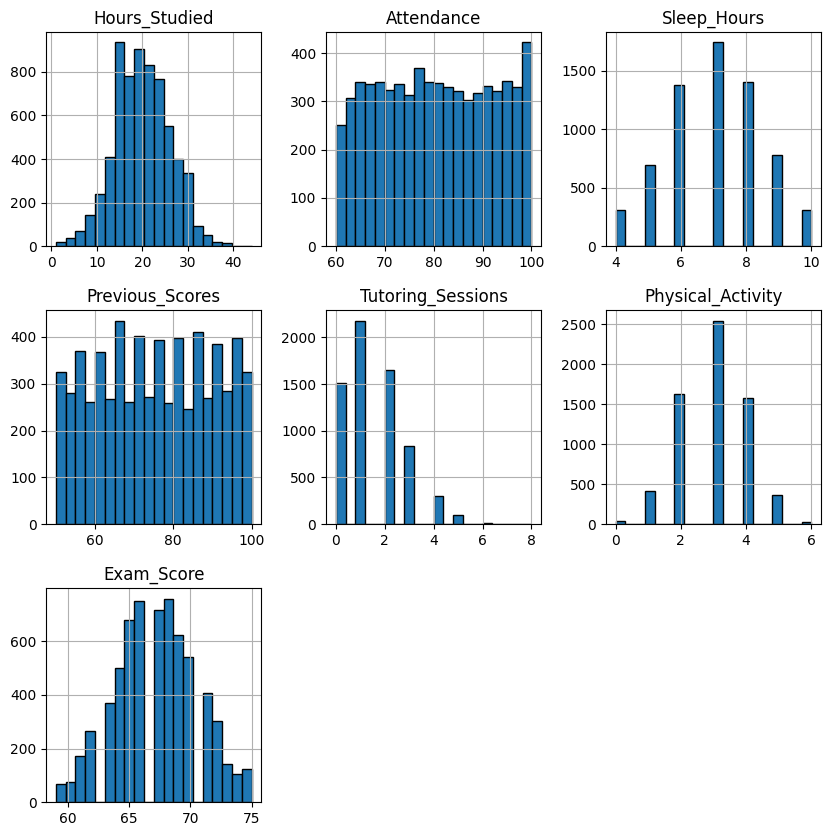

In [31]:
df.hist(bins=20,edgecolor='black',figsize=(10,10))
plt.show()

*Skweness* ➡ Apply transformations



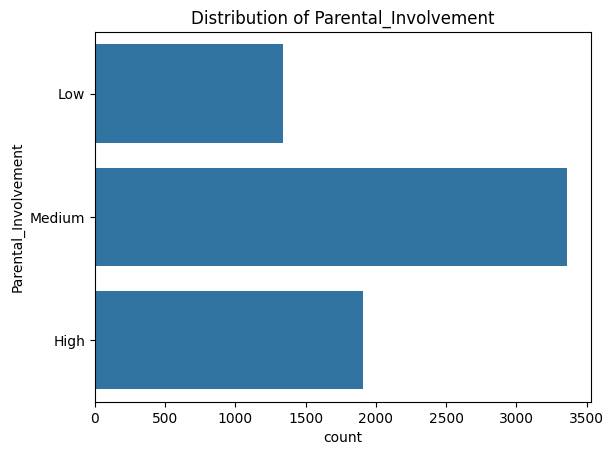

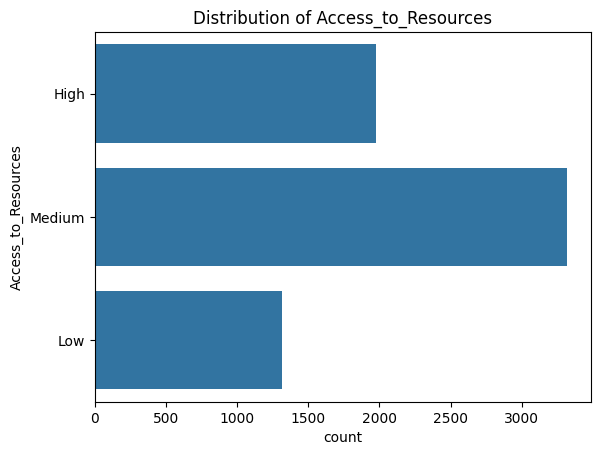

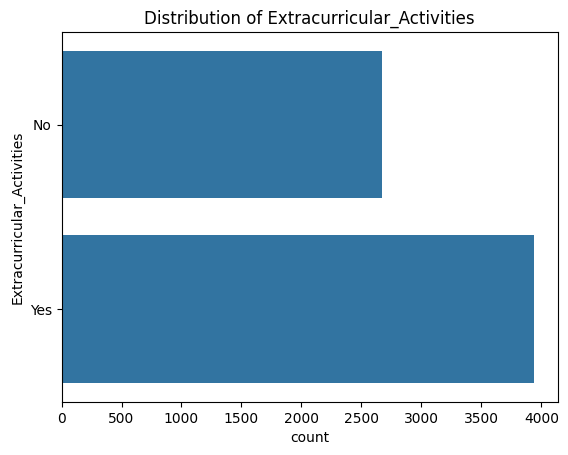

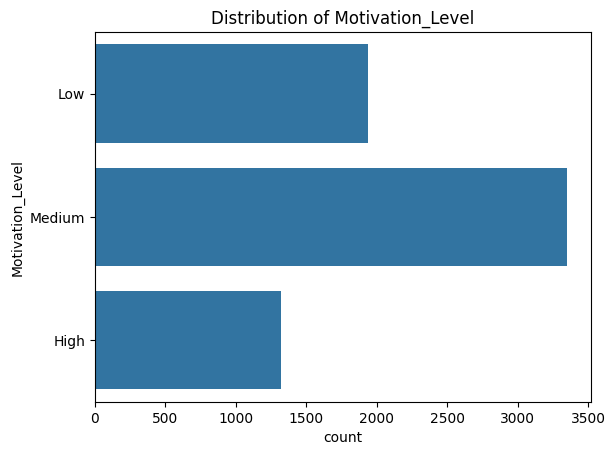

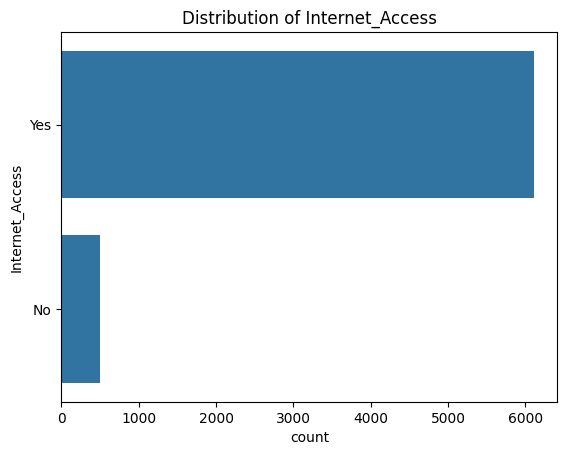

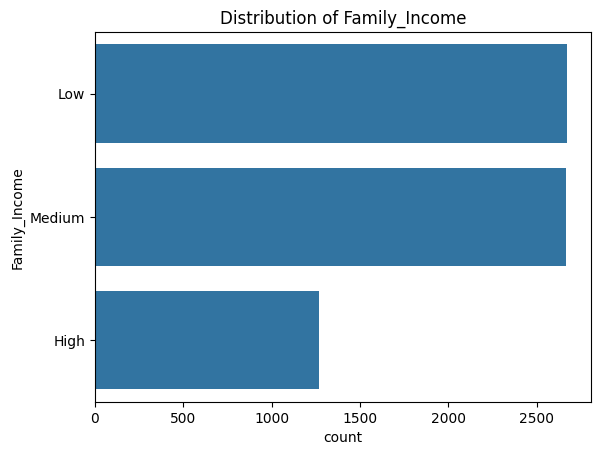

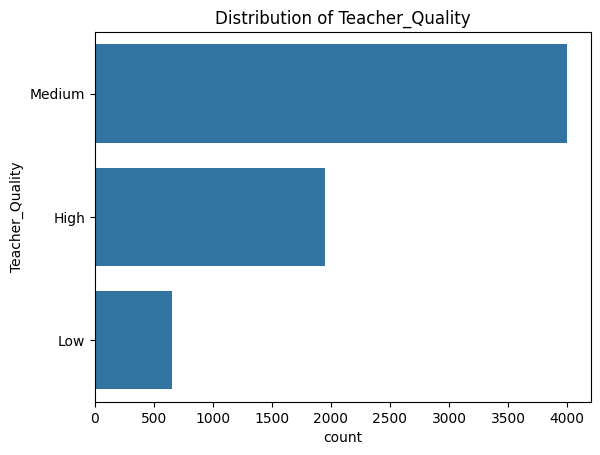

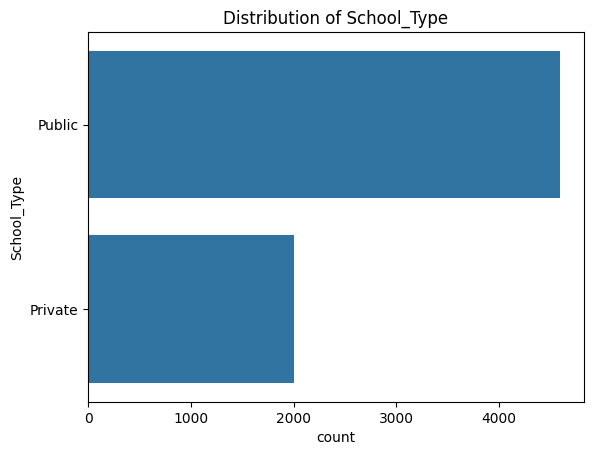

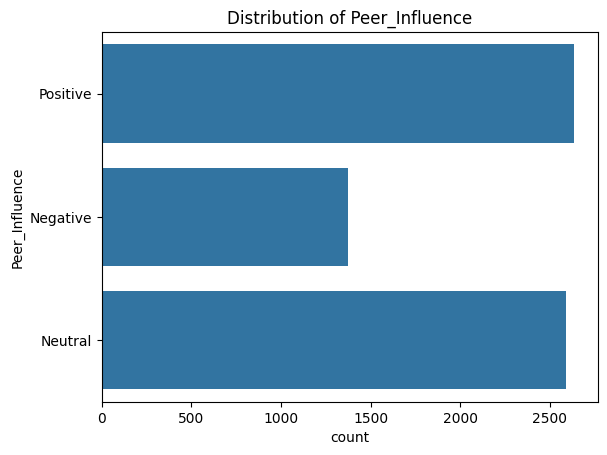

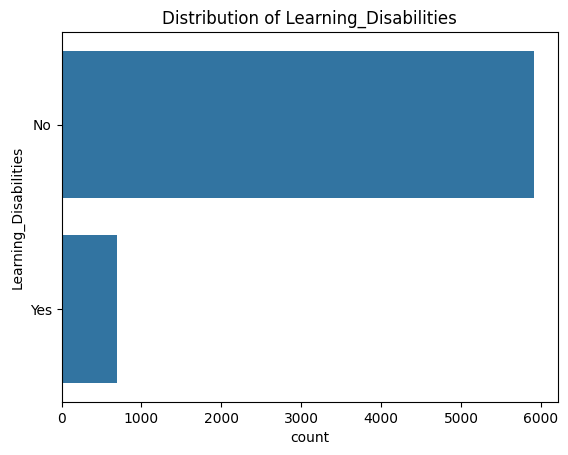

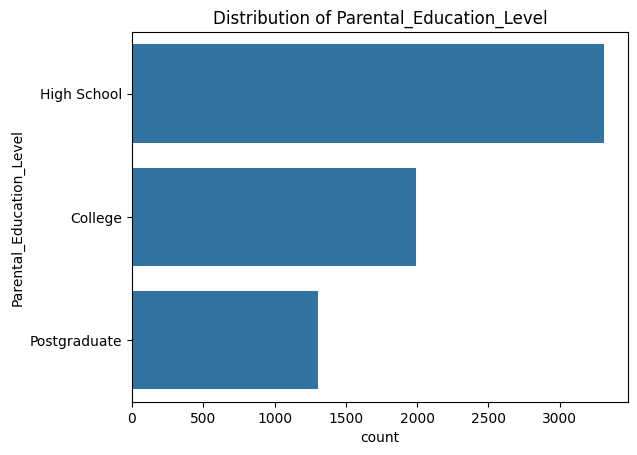

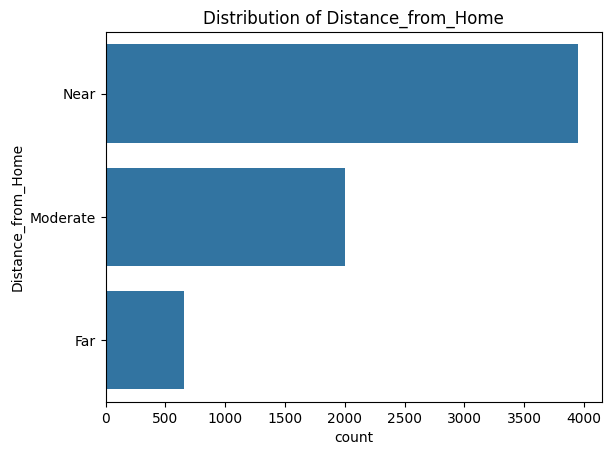

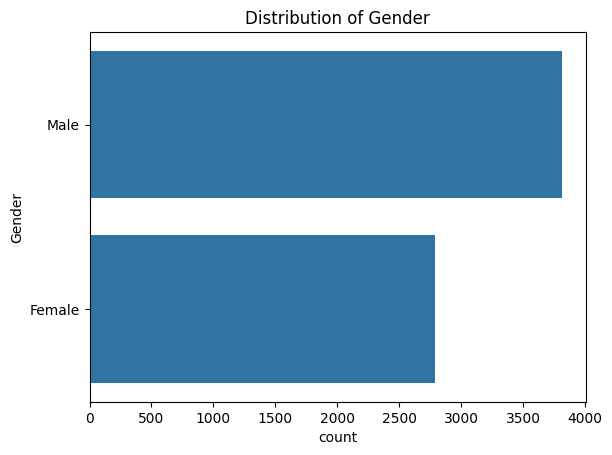

In [32]:
for c in cat :
  sns.countplot(df[c])
  plt.title(f"Distribution of {c}")
  plt.show()

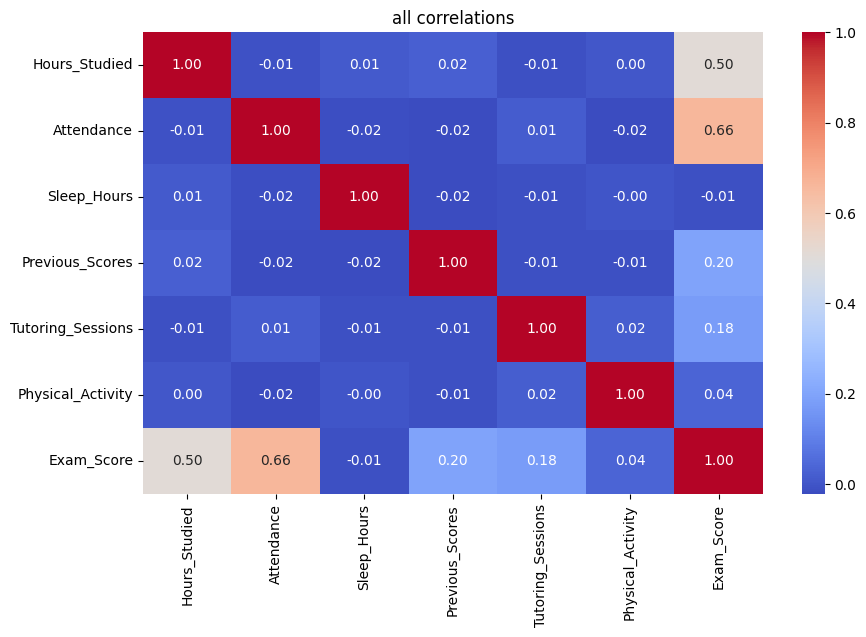

In [33]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('all correlations')
plt.show()

<Axes: xlabel='Hours_Studied', ylabel='Count'>

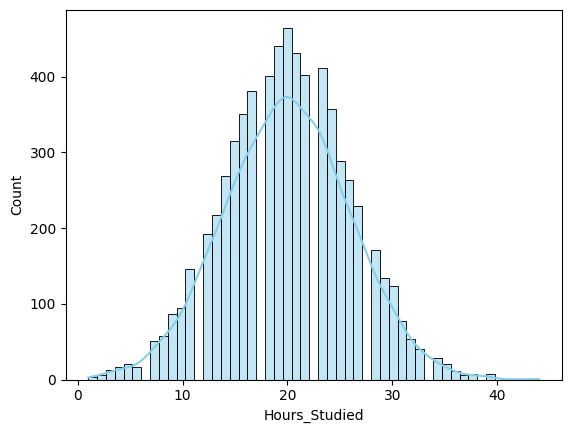

In [34]:
sns.histplot(df['Hours_Studied'], kde=True, color='skyblue')

<Axes: xlabel='Hours_Studied', ylabel='Exam_Score'>

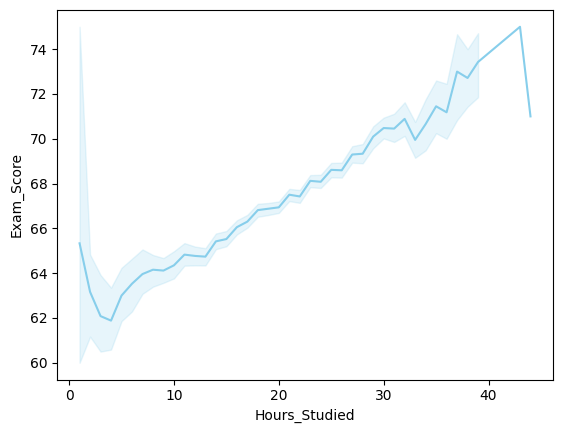

In [35]:
sns.lineplot(data=df, x='Hours_Studied', y='Exam_Score', color='skyblue')

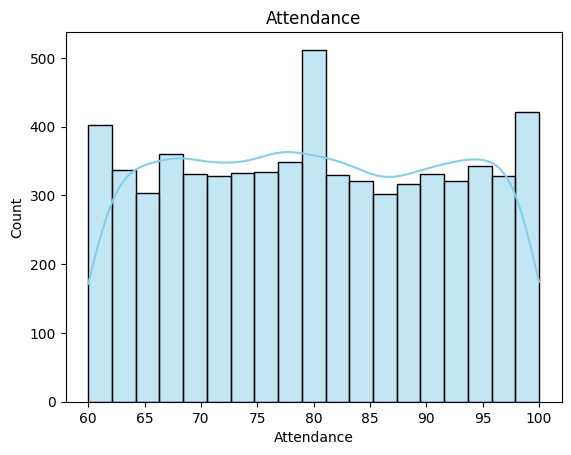

In [36]:
sns.histplot(df['Attendance'], kde=True, color='skyblue')
plt.title('Attendance')
plt.show()

<Axes: xlabel='Attendance', ylabel='Exam_Score'>

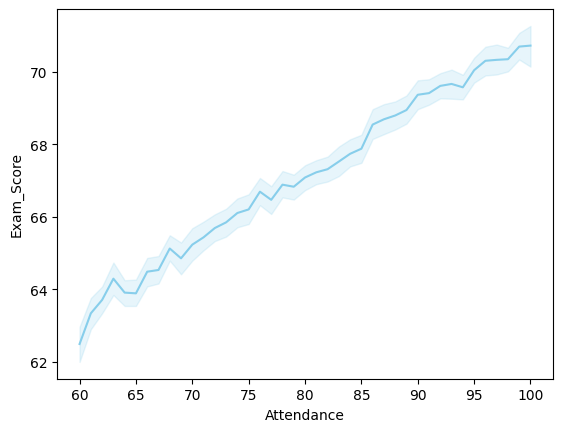

In [37]:
sns.lineplot(data=df, x='Attendance', y='Exam_Score', color='skyblue')

<Axes: xlabel='Tutoring_Sessions', ylabel='Exam_Score'>

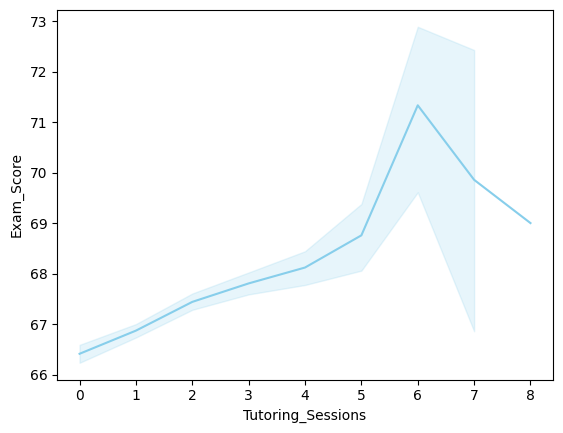

In [38]:
sns.lineplot(data=df, x='Tutoring_Sessions', y='Exam_Score', color='skyblue')

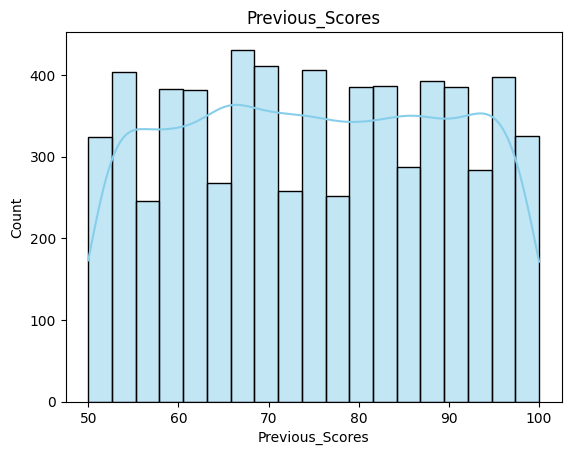

In [39]:
sns.histplot(df['Previous_Scores'], kde=True, color='skyblue')
plt.title('Previous_Scores')
plt.show()

<Axes: xlabel='Previous_Scores', ylabel='Exam_Score'>

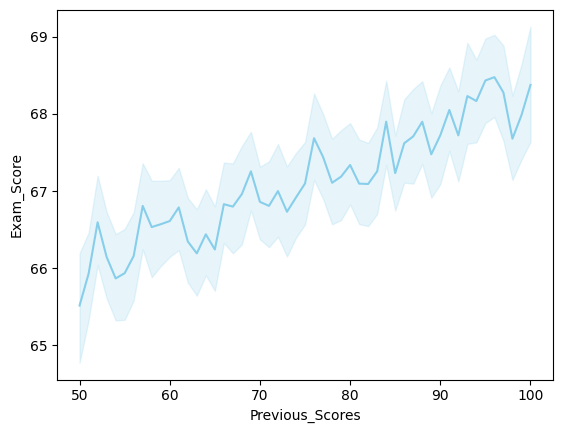

In [40]:
sns.lineplot(data=df, x='Previous_Scores', y='Exam_Score', color='skyblue')

**handling outliers**
-> 99.7% of data should lie within 3 standard deviations of the mean.

### other features

/tmp/ipykernel_504/365775302.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='Internet_Access', palette='coolwarm')


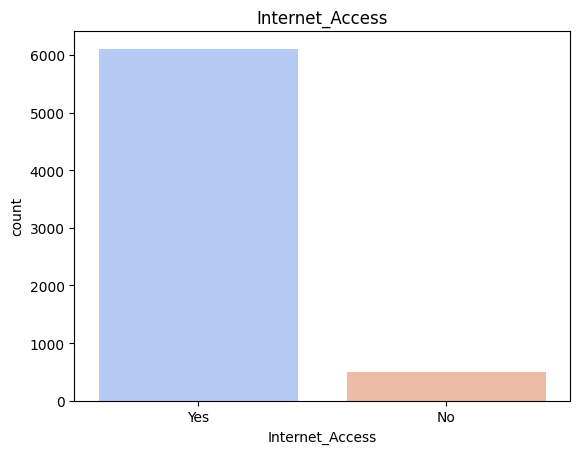

In [41]:
sns.countplot(df, x='Internet_Access', palette='coolwarm')
plt.title('Internet_Access')
plt.show()

/tmp/ipykernel_504/947826393.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='Gender', palette='coolwarm')


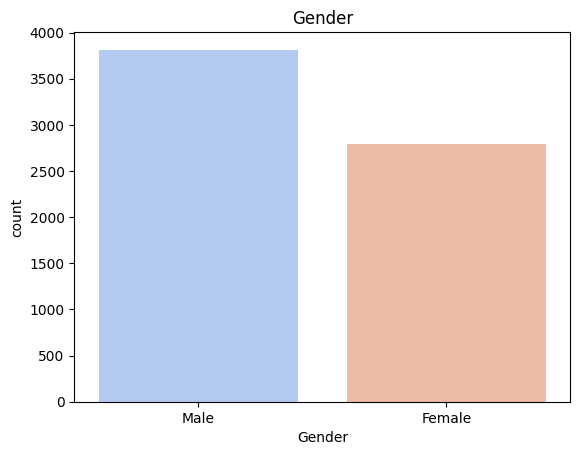

In [42]:
sns.countplot(df, x='Gender', palette='coolwarm')
plt.title('Gender')
plt.show()

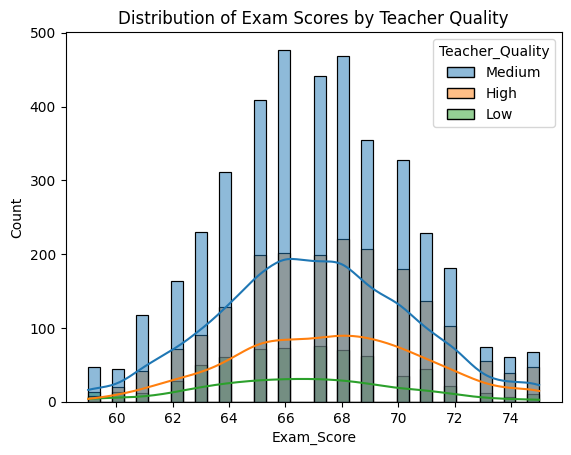

In [43]:
sns.histplot(data=df, x='Exam_Score', hue='Teacher_Quality', kde=True)
plt.title('Distribution of Exam Scores by Teacher Quality')
plt.show()

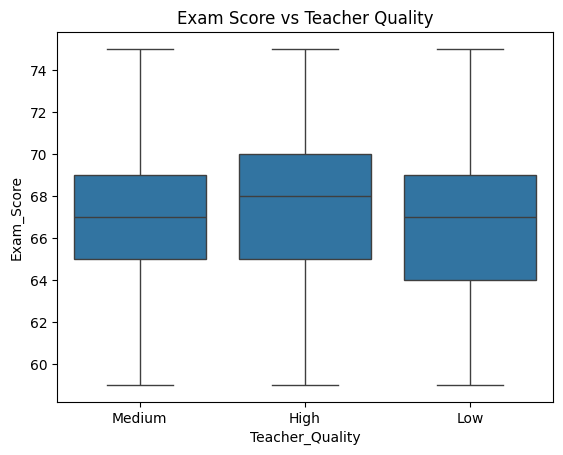

In [44]:
sns.boxplot(x='Teacher_Quality', y='Exam_Score', data=df)
plt.title('Exam Score vs Teacher Quality')
plt.show()

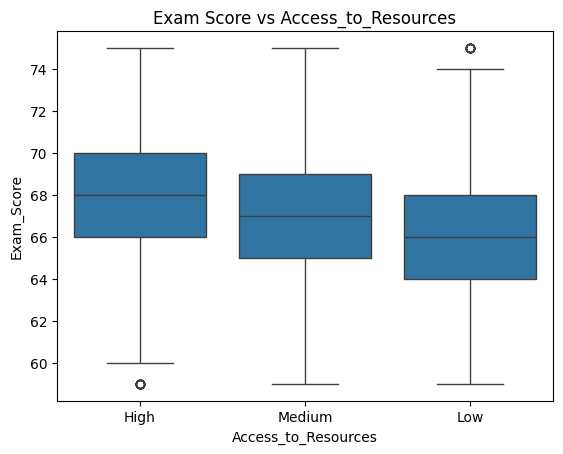

In [45]:
sns.boxplot(x='Access_to_Resources', y='Exam_Score', data=df)
plt.title('Exam Score vs Access_to_Resources')
plt.show()

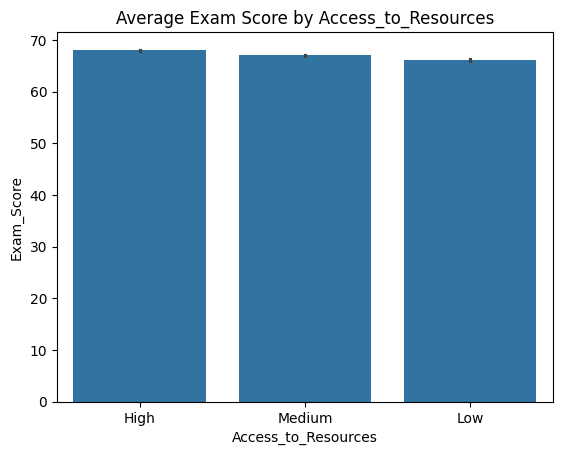

In [46]:
sns.barplot(x='Access_to_Resources', y='Exam_Score', data=df, estimator='mean')
plt.title('Average Exam Score by Access_to_Resources')
plt.show()

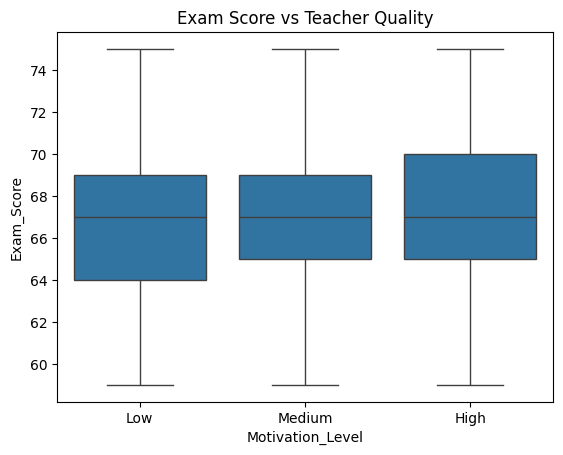

In [47]:
sns.boxplot(x='Motivation_Level', y='Exam_Score', data=df)
plt.title('Exam Score vs Teacher Quality')
plt.show()

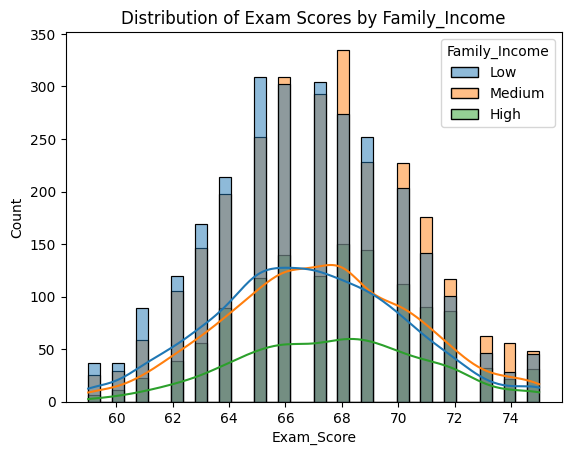

In [48]:
sns.histplot(data=df, x='Exam_Score', hue='Family_Income', kde=True)
plt.title('Distribution of Exam Scores by Family_Income')
plt.show()

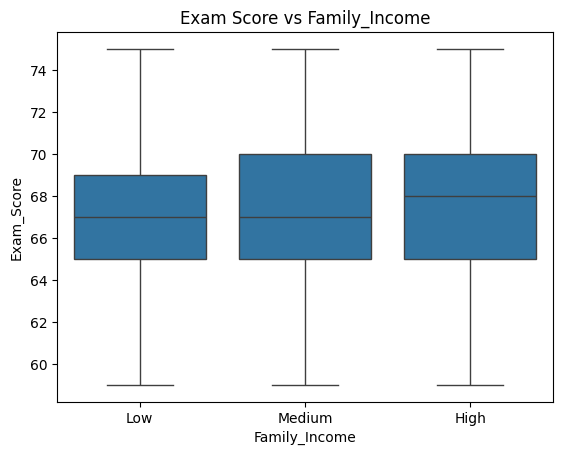

In [49]:
sns.boxplot(x='Family_Income', y='Exam_Score', data=df)
plt.title('Exam Score vs Family_Income')
plt.show()

# Splitting

In [50]:
X = no_outliers.drop("Exam_Score", axis=1)
y = no_outliers["Exam_Score"]

In [51]:
cat_cols=X.select_dtypes(include = ['object']).columns
num_cols=X.select_dtypes(include = ['int64']).columns

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
print(X_train.shape, X_test.shape)

(5202, 19) (1301, 19)


# Encoding & Scaling

In [54]:
scaler=StandardScaler()

In [55]:
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

In [56]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_cols, index=X_test.index)

In [57]:
encoder = OneHotEncoder(drop="first", handle_unknown="ignore")
X_train_encoded = encoder.fit_transform(X_train[cat])
X_test_encoded = encoder.transform(X_test[cat])

In [58]:
X_train_encoded = pd.DataFrame(
    X_train_encoded.toarray(),
    columns=encoder.get_feature_names_out(cat),
    index=X_train.index
)

In [59]:
X_test_encoded = pd.DataFrame(
    X_test_encoded.toarray(),
    columns=encoder.get_feature_names_out(cat),
    index=X_test.index
)

In [60]:
X_train_encoded

,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_Yes,Motivation_Level_Low,Motivation_Level_Medium,Internet_Access_Yes,Family_Income_Low,Family_Income_Medium,...,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Parental_Education_Level_nan,Distance_from_Home_Moderate,Distance_from_Home_Near,Distance_from_Home_nan,Gender_Male
2381,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1643,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5810,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
633,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
69,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3837,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
5280,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
5315,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
5479,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [61]:
X_train_tomodel = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test_tomodel  = pd.concat([X_test_scaled, X_test_encoded], axis=1)

In [62]:
X_train_tomodel.shape
X_test_tomodel.shape

(1301, 30)

In [63]:
X_train_tomodel = X_train_tomodel.dropna()
y_train = y_train.loc[X_train_tomodel.index]

X_test_tomodel = X_test_tomodel.dropna()
y_test = y_test.loc[X_test_tomodel.index]

# Linear Regression

In [64]:
model=LinearRegression()

In [65]:
model.fit(X_train_tomodel,y_train)

LinearRegression()

In [66]:
y_pred=model.predict(X_test_tomodel)

In [67]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.27047682499980014
MSE: 0.10467023904874644
RMSE: 0.3235278025900501
R²: 0.9899433142969226


#Polynomial Regression (Bonus)

In [68]:
poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

In [69]:
poly_model.fit(X_train_tomodel, y_train)

Pipeline(steps=[('poly_features', PolynomialFeatures(include_bias=False)),
                ('regressor', LinearRegression())])

In [70]:
y_pred_train = poly_model.predict(X_train_tomodel)
y_pred_test = poly_model.predict(X_test_tomodel)

In [71]:
print("Train RMSE:", mean_squared_error(y_train, y_pred_train))
print("Test RMSE:", mean_squared_error(y_test, y_pred_test))
print("R² (Train):", r2_score(y_train, y_pred_train))
print("R² (Test):", r2_score(y_test, y_pred_test))

Train RMSE: 0.09287227067966194
Test RMSE: 0.11772220996272653
R² (Train): 0.991220725280093
R² (Test): 0.9886892847802184


# Feature Selection (Bonus)

selected features:

gender

hours studied

attendance

previous score

tutoring sessions

teacher quality

Parental_Involvement ,

Extracurricular_Activities

Family_Income,

Parental_Education_Level

In [72]:
features_to_keep = [
    'Gender',
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Teacher_Quality',
    'Parental_Involvement',
    'Extracurricular_Activities',
    'Family_Income',
    'Parental_Education_Level',
    'Exam_Score'
]

In [73]:
df_two=no_outliers.copy()
df_two =no_outliers[features_to_keep]

In [74]:
X = df_two.drop("Exam_Score", axis=1)
y = df_two["Exam_Score"]

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [76]:
cat_selected = ['Gender','Extracurricular_Activities','Parental_Involvement', 'Teacher_Quality', 'Family_Income', 'Parental_Education_Level']
num_selected =['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions']

In [77]:
X_train_scaled = scaler.fit_transform(X_train[num_selected])
X_test_scaled = scaler.transform(X_test[num_selected])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_selected, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_selected, index=X_test.index)

In [79]:
encoder = OneHotEncoder(drop="first", handle_unknown="ignore")
X_train_encoded = encoder.fit_transform(X_train[cat_selected])
X_test_encoded = encoder.transform(X_test[cat_selected])

X_train_encoded = pd.DataFrame(
    X_train_encoded.toarray(),
    columns=encoder.get_feature_names_out(cat_selected),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded.toarray(),
    columns=encoder.get_feature_names_out(cat_selected),
    index=X_test.index
)

X_train_tomodel2 = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test_tomodel2= pd.concat([X_test_scaled, X_test_encoded], axis=1)

X_train_tomodel2 = X_train_tomodel.dropna()
y_train2 = y_train.loc[X_train_tomodel.index]

X_test_tomodel2 = X_test_tomodel.dropna()
y_test2 = y_test.loc[X_test_tomodel.index]

In [80]:
model.fit(X_train_tomodel2,y_train2)

LinearRegression()

In [81]:
y_pred2=model.predict(X_test_tomodel2)

In [82]:
mae = mean_absolute_error(y_test2, y_pred2)
mse = mean_squared_error(y_test2, y_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred2)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.8655103983829482
MSE: 1.160631487757599
RMSE: 1.077326082371349
R²: 0.8884868688984513
